# Data Wrangling y Calidad de Datos — Reto Assist v10

Este notebook documenta el análisis de calidad de datos para las tablas principales del reto hospitalario.

El objetivo no es entrenar modelos, sino revisar calidad de datos, validar integraciones entre tablas y justificar decisiones de limpieza implementadas en el pipeline de Data Engineering con Kedro.

Casos de uso considerados:

- **HIS-05:** saturación / tiempos de espera.
- **HIS-10:** predicción de inasistencia o No-Show.

## 1. Configuración inicial

Se cargan librerías, rutas del proyecto y funciones del pipeline formal de Data Engineering.

In [72]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "01_raw"
DATA_INTERMEDIATE = PROJECT_ROOT / "data" / "02_intermediate"
DATA_PRIMARY = PROJECT_ROOT / "data" / "03_primary"

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from assist_v10.pipelines.data_engineering.nodes import (
    clean_hospac,
    clean_hosagd,
    clean_hosmpi,
    clean_triage,
    clean_notamedicaurg,
    create_his10_base,
    create_his05_master_table,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

print("Project root:", PROJECT_ROOT)
print("Raw data path:", DATA_RAW)

Project root: c:\Users\seale\OneDrive\Documentos\DesarrolloDeProyectosDeIngenieriaMatematica\Reto\Repositorios\tca-reto
Raw data path: c:\Users\seale\OneDrive\Documentos\DesarrolloDeProyectosDeIngenieriaMatematica\Reto\Repositorios\tca-reto\data\01_raw


## 2. Carga de tablas crudas

Se cargan las cinco tablas principales usadas en el MVP:

- `HOSPAC`: episodios / información asociada a paciente y reservación.
- `HOSAGD`: agenda de citas médicas; tabla principal para HIS-10.
- `HOSMPI`: índice maestro de pacientes / datos demográficos.
- `NOTAMEDICAURG`: notas médicas de urgencias; base para HIS-05.
- `TRIAGE`: clasificación inicial de urgencias; enriquecimiento para HIS-05.

In [73]:
raw_tables = {
    "hospac": pd.read_parquet(DATA_RAW / "hospac.parquet"),
    "hosagd": pd.read_parquet(DATA_RAW / "hosagd.parquet"),
    "hosmpi": pd.read_parquet(DATA_RAW / "hosmpi.parquet"),
    "notamedicaurg": pd.read_parquet(DATA_RAW / "notamedicaurg.parquet"),
    "triage": pd.read_parquet(DATA_RAW / "triage.parquet"),
}

summary = pd.DataFrame({
    "table": list(raw_tables.keys()),
    "rows": [df.shape[0] for df in raw_tables.values()],
    "columns": [df.shape[1] for df in raw_tables.values()],
})

summary

,table,rows,columns
0,hospac,115593,106
1,hosagd,73018,15
2,hosmpi,37460,24
3,notamedicaurg,22878,70
4,triage,9942,21


## 3. Calidad inicial: tipos, nulos y duplicados

Se revisa el estado inicial de las tablas crudas antes de aplicar las limpiezas formales.

In [74]:
def missing_summary(df):
    out = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "dtype": [str(t) for t in df.dtypes],
    })
    return out.sort_values("missing_pct", ascending=False)

for name, df in raw_tables.items():
    print("=" * 80)
    print(name.upper())
    print("shape:", df.shape)
    print("duplicated full rows:", df.duplicated().sum())
    display(missing_summary(df).head(15))

HOSPAC
shape: (115593, 106)
duplicated full rows: 0


,column,missing_count,missing_pct,dtype
105,InternoExterno,3168,2.74,object
0,ibuff,0,0.00,object
2,p_area,0,0.00,object
3,p_area_ori,0,0.00,object
4,p_status,0,0.00,object
5,p_res_cve_num,0,0.00,object
6,p_res_cve_mbo,0,0.00,object
7,p_res_fec,0,0.00,object
8,p_res_hra,0,0.00,object
1,p_num_exp,0,0.00,object


HOSAGD
shape: (73018, 15)
duplicated full rows: 0


,column,missing_count,missing_pct,dtype
0,med,0,0.0,object
1,esp,0,0.0,object
2,a_fecha,0,0.0,object
3,area,0,0.0,object
4,cve_num,0,0.0,object
5,cve_mbo,0,0.0,object
6,dur,0,0.0,int64
7,hra_ini,0,0.0,object
8,hra_fin,0,0.0,object
9,tpo_cita,0,0.0,object


HOSMPI
shape: (37460, 24)
duplicated full rows: 0


,column,missing_count,missing_pct,dtype
0,ibuff,0,0.0,object
1,m_status,0,0.0,object
2,m_num_exp,0,0.0,object
3,m_ficha_tra,0,0.0,object
4,m_sexo,0,0.0,object
5,m_civil,0,0.0,object
6,m_fec_nac,0,0.0,object
7,m_lug_nac,0,0.0,object
8,m_ciu,0,0.0,object
9,m_col,0,0.0,object


NOTAMEDICAURG
shape: (22878, 70)
duplicated full rows: 0


,column,missing_count,missing_pct,dtype
30,Plan1,2,0.01,object
16,Apreciativo,2,0.01,object
2,Edad,0,0.00,object
3,Sexo,0,0.00,object
0,Indice,0,0.00,float64
1,Expediente,0,0.00,object
5,Fecha,0,0.00,object
4,ClaveIngreso,0,0.00,object
8,Medico,0,0.00,object
6,Hora,0,0.00,object


TRIAGE
shape: (9942, 21)
duplicated full rows: 0


,column,missing_count,missing_pct,dtype
10,Area,9942,100.00,object
19,FechaNac,9941,99.99,object
20,EstatusReg,9941,99.99,object
9,Especialidad,4190,42.14,object
17,Destino,418,4.20,object
8,Medico,156,1.57,object
4,ClaveIngreso,0,0.00,object
2,Edad,0,0.00,object
1,Expediente,0,0.00,object
0,Indice,0,0.00,float64


### Interpretación de calidad inicial

Esta revisión permite identificar problemas generales antes de transformar los datos. En particular, se observan tipos de datos que no siempre corresponden con su significado real, como fechas y horas almacenadas como texto, además de valores faltantes y posibles duplicados.

Esta etapa es importante porque evita aplicar modelos directamente sobre datos crudos sin entender primero su estructura, consistencia y posibles riesgos de calidad.

## 4. Aplicación de limpiezas formales

Se aplican las funciones de limpieza implementadas en `nodes.py`.  
Esto conecta el análisis del notebook con el pipeline formal de Kedro.

In [75]:
processed_hospac = clean_hospac(raw_tables["hospac"])
processed_hosagd = clean_hosagd(raw_tables["hosagd"])
processed_hosmpi = clean_hosmpi(raw_tables["hosmpi"])
processed_triage = clean_triage(raw_tables["triage"])
processed_notamedicaurg = clean_notamedicaurg(raw_tables["notamedicaurg"])

processed_tables = {
    "processed_hospac": processed_hospac,
    "processed_hosagd": processed_hosagd,
    "processed_hosmpi": processed_hosmpi,
    "processed_triage": processed_triage,
    "processed_notamedicaurg": processed_notamedicaurg,
}

pd.DataFrame({
    "table": list(processed_tables.keys()),
    "rows": [df.shape[0] for df in processed_tables.values()],
    "columns": [df.shape[1] for df in processed_tables.values()],
})

,table,rows,columns
0,processed_hospac,115593,12
1,processed_hosagd,73018,25
2,processed_hosmpi,37460,10
3,processed_triage,9942,13
4,processed_notamedicaurg,22847,14


### Interpretación de la limpieza formal

Después de aplicar las funciones de limpieza, las tablas quedan más estandarizadas: se normalizan textos, se construyen llaves de unión, se convierten fechas y horas a tipos adecuados, y se crean variables útiles para modelado.

Esto muestra que el análisis de Data Wrangling no queda solo como exploración manual, sino que sus decisiones principales se implementan de forma reproducible en el pipeline de Kedro.

## 4.1 Validación de fechas

Además de convertir columnas a tipo fecha/hora, se revisan rangos, valores nulos después de la conversión y posibles fechas fuera de rango.

Esto es importante porque los modelos de HIS-05 y HIS-10 dependen de variables temporales como fecha de cita, fecha de llegada, fecha de reservación y fecha de nota médica.

In [76]:
date_columns = {
    "processed_hosagd": (processed_hosagd, ["appointment_datetime"]),
    "processed_hospac": (processed_hospac, ["reservation_datetime", "arrival_datetime", "registration_datetime"]),
    "processed_triage": (processed_triage, ["triage_datetime"]),
    "processed_notamedicaurg": (processed_notamedicaurg, ["arrival_datetime", "note_datetime", "destination_datetime"]),
}

date_rows = []

for table_name, (df, cols) in date_columns.items():
    for col in cols:
        if col not in df.columns:
            continue

        s = pd.to_datetime(df[col], errors="coerce")

        date_rows.append({
            "table": table_name,
            "column": col,
            "rows": len(df),
            "missing_dates": int(s.isna().sum()),
            "missing_pct": round(s.isna().mean() * 100, 2),
            "min_date": s.min(),
            "max_date": s.max(),
        })

date_validation = pd.DataFrame(date_rows)
date_validation

,table,column,rows,missing_dates,missing_pct,min_date,max_date
0,processed_hosagd,appointment_datetime,73018,0,0.00,2024-05-15 08:00:00,2222-01-03 19:00:00
1,processed_hospac,reservation_datetime,115593,8342,7.22,1964-10-17 09:32:04,2026-02-27 17:17:12
2,processed_hospac,arrival_datetime,115593,0,0.00,1963-05-15 13:17:47,2222-01-03 19:00:00
3,processed_hospac,registration_datetime,115593,35590,30.79,1963-05-15 13:17:47,2026-02-27 17:15:22
4,processed_triage,triage_datetime,9942,0,0.00,2024-10-04 11:26:37,2026-03-06 18:47:37
5,processed_notamedicaurg,arrival_datetime,22847,0,0.00,1963-05-15 13:17:47,2026-02-27 17:15:22
6,processed_notamedicaurg,note_datetime,22847,0,0.00,2024-10-04 12:37:12,2026-02-27 17:28:18
7,processed_notamedicaurg,destination_datetime,22847,21622,94.64,2024-10-04 15:55:45,2025-08-04 13:45:55


### Interpretación de validación de fechas

Esta revisión permite confirmar si las fechas convertidas tienen rangos razonables y si existen valores que no pudieron convertirse correctamente.

Las fechas faltantes o inválidas no siempre se deben eliminar automáticamente, porque su tratamiento depende del uso posterior. Por ejemplo, una fecha de reservación faltante puede afectar el cálculo de `lead_time_days`, mientras que una fecha de llegada faltante puede afectar el análisis de saturación.

## 4.2 Transformaciones implementadas en el pipeline

Aunque este notebook muestra el análisis de calidad de datos, varias transformaciones se implementan formalmente en el pipeline de Data Engineering con Kedro. Esto permite que la limpieza sea reproducible y no dependa de pasos manuales del notebook.

| Transformación | Descripción | Implementación |
|---|---|---|
| Limpieza de texto | Se eliminan espacios al inicio/final y strings vacíos se convierten en valores faltantes. | `_strip_string_columns()` |
| Estandarización de horas | Se convierten horas en distintos formatos al estándar `HHMMSS`. | `_standardize_time_hhmmss()` |
| Conversión de fechas | Se combinan columnas de fecha y hora para construir columnas `datetime`. | `_parse_datetime_from_date_time()` |
| Variables temporales | Se crean variables como hora, día de semana, mes y fin de semana. | `_add_temporal_features()` |
| Limpieza de HOSPAC | Se crean llaves normalizadas para unir episodios con agenda. | `clean_hospac()` |
| Limpieza de HOSAGD | Se limpia la agenda, se construye `appointment_datetime` y se crea el target `no_show`. | `clean_hosagd()` |
| Limpieza de HOSMPI | Se prepara información demográfica del paciente, como edad, sexo y ubicación. | `clean_hosmpi()` |
| Limpieza de TRIAGE | Se limpia información de clasificación inicial de urgencias. | `clean_triage()` |
| Limpieza de NOTAMEDICAURG | Se crea un proxy de espera usando `note_datetime - arrival_datetime`. | `clean_notamedicaurg()` |
| Dataset HIS-10 | Se integra `HOSAGD + HOSPAC + HOSMPI` para crear la base de No-Show. | `create_his10_base()` |
| Dataset HIS-05 | Se agregan llegadas, proxy de espera y triage por hora. | `create_his05_master_table()` |

Estas transformaciones son las que posteriormente ejecuta Kedro mediante:

`kedro run --pipeline data_engineering`

### Construcción del target de HIS-10

Para HIS-10, el target se construye a partir del campo `asistencia` de `HOSAGD`:

- `A` se interpreta como asistencia y se codifica como `no_show = 0`.
- `I` se interpreta como inasistencia y se codifica como `no_show = 1`.
- Los valores vacíos o desconocidos no se imputan, porque inventar el resultado real de una cita podría sesgar el modelo.

Por esta razón, el dataset inicial de HIS-10 solo conserva citas con asistencia conocida.

### Proxy de tiempo de espera para HIS-05

Para HIS-05, el tiempo oficial de atención no estaba disponible porque `AtMed_Hora` no contenía información suficiente. Por eso, se construyó un proxy de espera:

`wait_proxy_min = note_datetime - arrival_datetime`

Este valor no debe interpretarse como el tiempo oficial clínico de espera, sino como una aproximación operativa útil para el MVP. Los valores negativos o mayores a 24 horas se marcan como no válidos para el cálculo de métricas agregadas.

## 5. Integración e integridad referencial

Para HIS-10, la integración central es:

`HOSAGD + HOSPAC + HOSMPI`

La llave correcta entre `HOSAGD` y `HOSPAC` es:

`area + cve_num + cve_mbo`

No se debe unir solo con `cve_num + cve_mbo`, porque esas claves pueden repetirse entre áreas.

In [77]:
key_cols = ["area_key", "cve_num_key", "cve_mbo_key"]

hospac_by_key = (
    processed_hospac
    .sort_values(key_cols + ["registration_datetime"], na_position="last")
    .drop_duplicates(subset=key_cols, keep="first")
)

joined_hosagd_hospac = processed_hosagd.merge(
    hospac_by_key,
    on=key_cols,
    how="left",
    suffixes=("", "_hospac"),
)

match_rate_hospac = joined_hosagd_hospac["p_num_exp_key"].notna().mean() * 100

print("HOSAGD rows:", len(processed_hosagd))
print("Joined rows:", len(joined_hosagd_hospac))
print("Rows with HOSPAC match:", joined_hosagd_hospac["p_num_exp_key"].notna().sum())
print("Match rate:", round(match_rate_hospac, 2), "%")

HOSAGD rows: 73018
Joined rows: 73018
Rows with HOSPAC match: 73017
Match rate: 100.0 %


In [78]:
joined_patients = joined_hosagd_hospac.merge(
    processed_hosmpi,
    left_on="p_num_exp_key",
    right_on="m_num_exp_key",
    how="left",
)

match_rate_hosmpi = joined_patients["m_num_exp_key"].notna().mean() * 100

print("Rows after HOSPAC + HOSMPI join:", len(joined_patients))
print("Rows with HOSMPI match:", joined_patients["m_num_exp_key"].notna().sum())
print("Match rate:", round(match_rate_hosmpi, 2), "%")

Rows after HOSPAC + HOSMPI join: 73018
Rows with HOSMPI match: 60389
Match rate: 82.7 %


### Interpretación de integración e integridad referencial

La integración entre tablas es clave porque los casos de uso no dependen de una sola fuente. Para HIS-10, la agenda de citas necesita enriquecerse con información de pacientes y episodios.

El cruce entre `HOSAGD` y `HOSPAC` se realiza con `area + cve_num + cve_mbo`, ya que usar solo `cve_num + cve_mbo` puede generar duplicados. Esto reduce el riesgo de inflar artificialmente el número de citas o asignar información incorrecta a una cita.

## 6. Duplicados por llaves de negocio

No basta con revisar duplicados completos. También se revisan duplicados por llaves relevantes.

In [79]:
def duplicate_key_check(name, df, cols):
    existing_cols = [c for c in cols if c in df.columns]
    if len(existing_cols) != len(cols):
        return {
            "table": name,
            "key": " + ".join(cols),
            "status": "missing columns",
            "duplicated_keys": np.nan,
            "pct_rows_in_duplicated_keys": np.nan,
        }

    counts = df.groupby(existing_cols, dropna=False).size()
    duplicated_keys = (counts > 1).sum()
    rows_in_duplicated_keys = counts[counts > 1].sum()

    return {
        "table": name,
        "key": " + ".join(existing_cols),
        "status": "ok",
        "duplicated_keys": int(duplicated_keys),
        "pct_rows_in_duplicated_keys": round(rows_in_duplicated_keys / len(df) * 100, 2),
    }

checks = [
    duplicate_key_check("processed_hosagd", processed_hosagd, ["area_key", "cve_num_key", "cve_mbo_key"]),
    duplicate_key_check("processed_hospac", processed_hospac, ["area_key", "cve_num_key", "cve_mbo_key"]),
    duplicate_key_check("processed_hosmpi", processed_hosmpi, ["m_num_exp_key"]),
    duplicate_key_check("processed_triage", processed_triage, ["clave_ingreso_key"]),
    duplicate_key_check("processed_notamedicaurg", processed_notamedicaurg, ["clave_ingreso_key"]),
]

pd.DataFrame(checks)

,table,key,status,duplicated_keys,pct_rows_in_duplicated_keys
0,processed_hosagd,area_key + cve_num_key + cve_mbo_key,ok,0,0.00
1,processed_hospac,area_key + cve_num_key + cve_mbo_key,ok,0,0.00
2,processed_hosmpi,m_num_exp_key,ok,0,0.00
3,processed_triage,clave_ingreso_key,ok,19,0.38
4,processed_notamedicaurg,clave_ingreso_key,ok,8670,96.91


### Interpretación de duplicados

La revisión de duplicados por llaves de negocio permite detectar si una misma entidad aparece más de una vez bajo la misma clave. Esto es más relevante que revisar únicamente filas idénticas, porque en datos operacionales puede haber registros casi iguales pero con pequeñas diferencias.

Cuando existen duplicados por llave, se debe decidir si representan eventos reales repetidos o si son registros redundantes. En el pipeline se evita duplicar citas al seleccionar un solo registro de `HOSPAC` por llave de unión antes de construir la base de HIS-10.

## 7. Faltantes y decisiones de tratamiento

Decisiones principales:

- Los valores categóricos faltantes pueden tratarse como `UNKNOWN`.
- Los valores numéricos faltantes no se imputan en Data Engineering; se dejan para modelado.
- El target `asistencia` no se imputa. Solo se usan registros con `A` o `I`.
- Como `AtMed_Hora` está vacío, se usa un proxy de espera basado en `note_datetime - arrival_datetime`.

In [80]:
print("HOSAGD asistencia distribution:")
display(processed_hosagd["asistencia_clean"].value_counts(dropna=False).to_frame("count"))

print("\nNOTAMEDICAURG wait proxy validity:")
display(processed_notamedicaurg["valid_wait_proxy"].value_counts(dropna=False).to_frame("count"))

for name, df in processed_tables.items():
    print("=" * 80)
    print(name.upper())
    display(missing_summary(df).head(10))

HOSAGD asistencia distribution:


,count
asistencia_clean,
<NA>,44463
A,21325
I,7226
,3
,1



NOTAMEDICAURG wait proxy validity:


,count
valid_wait_proxy,
1,21369
0,1478


PROCESSED_HOSPAC


...

,column,missing_count,missing_pct,dtype
3,m_edad_num,37452,99.98,Int64
6,m_col,34108,91.05,string
7,m_cp,33570,89.62,string
8,m_edo,31054,82.90,string
5,m_ciu,30585,81.65,string
9,m_pai,30355,81.03,string
4,m_fec_nac_clean,8,0.02,datetime64[ns]
0,m_num_exp_key,0,0.00,string
1,m_status,0,0.00,string
2,m_sexo,0,0.00,string


PROCESSED_TRIAGE


,column,missing_count,missing_pct,dtype
5,Area,9942,100.00,string
12,TiempoEvolucion,2423,24.37,string
11,Destino,442,4.45,string
7,NomDepartamento,3,0.03,string
0,expediente_key,0,0.00,string
4,Sexo,0,0.00,string
3,Edad,0,0.00,string
2,triage_datetime,0,0.00,datetime64[ns]
1,clave_ingreso_key,0,0.00,string
8,LlegadaServicio,0,0.00,string


PROCESSED_NOTAMEDICAURG


,column,missing_count,missing_pct,dtype
4,destination_datetime,21622,94.64,datetime64[ns]
9,Especialidad,72,0.32,string
10,LlegadaServicio,8,0.04,string
11,MotivoConsulta,9,0.04,string
12,Triage,8,0.04,string
0,expediente_key,0,0.00,string
5,wait_proxy_min,0,0.00,float64
3,note_datetime,0,0.00,datetime64[ns]
2,arrival_datetime,0,0.00,datetime64[ns]
1,clave_ingreso_key,0,0.00,string


### Interpretación de faltantes

Los valores faltantes no se tratan todos de la misma forma. En variables categóricas, los faltantes pueden conservarse como una categoría explícita (`UNKNOWN`) para que el modelo no pierda registros útiles.

En cambio, los valores numéricos faltantes no se imputan en esta etapa, porque la imputación depende del modelo y debe evaluarse durante Data Science. Además, el campo `asistencia` no se imputa porque representa la variable objetivo de HIS-10; inventar ese valor podría sesgar el modelo.

## 8. Construcción de datasets finales

Se construyen las dos bases finales para los casos de uso.

In [81]:
preprocessed_data_his10 = create_his10_base(
    processed_hosagd=processed_hosagd,
    processed_hospac=processed_hospac,
    processed_hosmpi=processed_hosmpi,
)

master_table_his05 = create_his05_master_table(
    processed_notamedicaurg=processed_notamedicaurg,
    processed_triage=processed_triage,
)

print("preprocessed_data_his10:", preprocessed_data_his10.shape)
print("master_table_his05:", master_table_his05.shape)

preprocessed_data_his10: (28551, 27)
master_table_his05: (3132, 16)


### Interpretación de datasets finales

Los datasets finales resumen el resultado práctico del Data Wrangling. `preprocessed_data_his10` queda como base para clasificar No-Show, mientras que `master_table_his05` queda como base horaria para analizar saturación y tiempos de espera.

Esto confirma que las tablas crudas sí pueden transformarse en estructuras útiles para los dos casos de uso seleccionados.

### Nota sobre variables candidatas para modelado

Las variables analizadas en este notebook deben interpretarse como **variables candidatas**, no como selección final del modelo.

La etapa de Data Wrangling prepara, limpia y documenta variables potencialmente útiles, pero la selección definitiva corresponde a la etapa de Data Science. Ahí se deben evaluar desempeño, leakage, importancia de variables, cardinalidad, imputación y métricas del modelo.

## 9. Variables continuas

Se revisan variables continuas relevantes para detectar valores imposibles, outliers y distribuciones altamente sesgadas.

In [82]:
def continuous_profile(df, cols):
    rows = []

    for col in cols:
        if col not in df.columns:
            continue

        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        rows.append({
            "column": col,
            "count": int(s.count()),
            "missing": int(df[col].isna().sum()),
            "min": s.min(),
            "q1": q1,
            "median": s.median(),
            "mean": s.mean(),
            "q3": q3,
            "max": s.max(),
            "std": s.std(),
            "skew": s.skew(),
            "iqr_outliers": int(((s < lower) | (s > upper)).sum()),
        })

    return pd.DataFrame(rows)

his10_continuous = [
    "duration_min",
    "appointment_hour",
    "appointment_day_of_week",
    "appointment_day",
    "appointment_month",
    "lead_time_days",
    "m_edad_num",
]

his05_continuous = [
    "pacientes_llegando",
    "tiempo_espera",
    "tiempo_espera_mediana",
    "wait_proxy_valid_count",
    "hour",
    "day_of_week",
    "month",
]

print("HIS-10 continuous variables")
display(continuous_profile(preprocessed_data_his10, his10_continuous))

print("HIS-05 continuous variables")
display(continuous_profile(master_table_his05, his05_continuous))

HIS-10 continuous variables


,column,count,missing,min,q1,median,mean,q3,max,std,skew,iqr_outliers
0,duration_min,28551,0,15.0,30.000000,30.000000,40.595251,60.000000,100.000000,15.174881,0.390595,0
1,appointment_hour,28551,0,6.0,10.000000,12.000000,12.510105,14.000000,22.000000,3.048888,0.716678,161
2,appointment_day_of_week,28551,0,0.0,1.000000,2.000000,2.356765,4.000000,6.000000,1.671058,0.137563,0
3,appointment_day,28551,0,1.0,8.000000,16.000000,15.831109,23.000000,31.000000,8.605146,0.019828,0
4,appointment_month,28551,0,1.0,3.000000,5.000000,5.633078,10.000000,12.000000,3.642386,0.520135,0
5,lead_time_days,25923,2628,0.0,0.935509,2.675822,6.997522,6.769068,213.823067,13.567134,5.069466,2948
6,m_edad_num,2,28549,113.0,116.000000,119.000000,119.000000,122.000000,125.000000,8.485281,<NA>,0


HIS-05 continuous variables


,column,count,missing,min,q1,median,mean,q3,max,std,skew,iqr_outliers
0,pacientes_llegando,3132,0,1.000000,3.000000,6.000000,7.294700,10.000000,49.000000,5.971747,1.736857,114
1,tiempo_espera,3097,35,0.662500,37.577778,69.673333,110.804097,128.575000,1349.900000,137.236657,3.770242,247
2,tiempo_espera_mediana,3097,35,0.383333,29.925000,56.166667,92.828127,100.008333,1431.516667,142.278313,4.990428,256
3,wait_proxy_valid_count,3132,0,0.000000,2.000000,5.000000,6.822797,9.000000,49.000000,5.719032,1.766324,110
4,hour,3132,0,0.000000,9.000000,13.000000,12.738186,18.000000,23.000000,6.229029,-0.272830,0
5,day_of_week,3132,0,0.000000,1.000000,3.000000,2.965837,5.000000,6.000000,2.000906,0.013240,0
6,month,3132,0,1.000000,3.000000,4.000000,4.439017,5.000000,12.000000,2.581248,1.401915,284


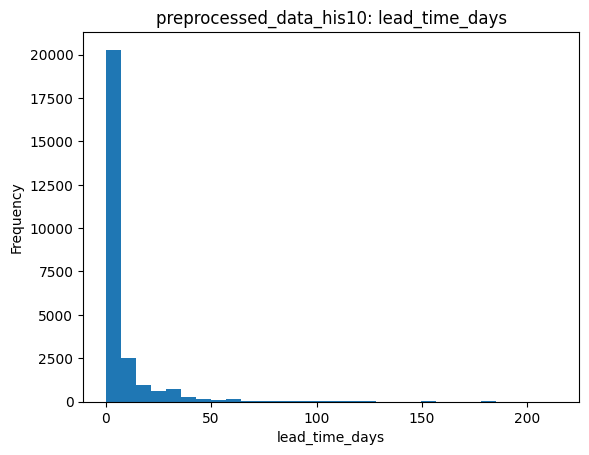

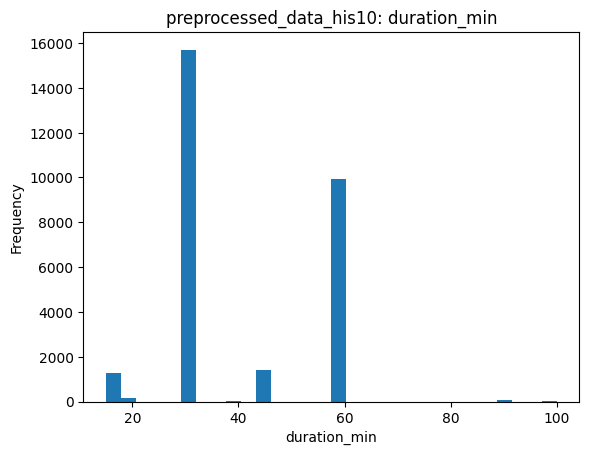

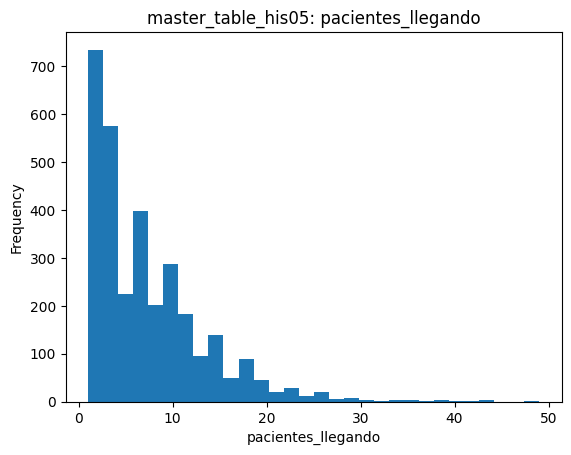

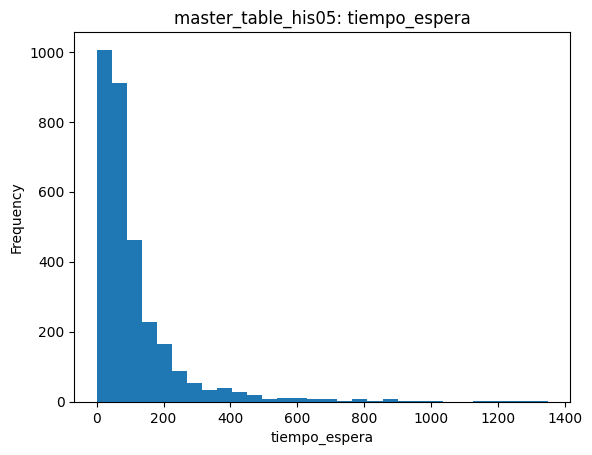

In [83]:
plot_cols = [
    ("preprocessed_data_his10", preprocessed_data_his10, "lead_time_days"),
    ("preprocessed_data_his10", preprocessed_data_his10, "duration_min"),
    ("master_table_his05", master_table_his05, "pacientes_llegando"),
    ("master_table_his05", master_table_his05, "tiempo_espera"),
]

for table_name, df, col in plot_cols:
    if col in df.columns:
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if not s.empty:
            plt.figure()
            plt.hist(s, bins=30)
            plt.title(f"{table_name}: {col}")
            plt.xlabel(col)
            plt.ylabel("Frequency")
            plt.show()

### Interpretación de variables continuas, outliers y normalidad

Las variables continuas se revisan mediante estadísticos descriptivos, sesgo, histogramas y detección exploratoria de outliers por IQR. Este análisis permite identificar valores extremos, posibles errores de captura o distribuciones muy asimétricas.

La normalidad se revisa de forma exploratoria, no como requisito estricto, porque los modelos propuestos para el proyecto no dependen directamente de que las variables sigan una distribución normal. Aun así, conocer la forma de las distribuciones ayuda a decidir si conviene transformar, limitar outliers o usar métricas robustas.

## 9.1 Revisión de valores imposibles

Además de outliers, se revisan reglas básicas de valores imposibles o sospechosos.

Estas reglas no necesariamente eliminan datos en automático, pero ayudan a identificar registros que deben tratarse con cuidado en etapas posteriores.

In [84]:
impossible_checks = []

def add_impossible_check(table_name, df, column, condition, description):
    if column not in df.columns:
        return

    s = pd.to_numeric(df[column], errors="coerce")
    mask = condition(s)

    impossible_checks.append({
        "table": table_name,
        "column": column,
        "rule": description,
        "count": int(mask.sum()),
        "pct": round(mask.mean() * 100, 2),
    })

add_impossible_check(
    "preprocessed_data_his10",
    preprocessed_data_his10,
    "duration_min",
    lambda s: s < 0,
    "duration_min < 0",
)

add_impossible_check(
    "preprocessed_data_his10",
    preprocessed_data_his10,
    "appointment_hour",
    lambda s: (s < 0) | (s > 23),
    "appointment_hour outside 0-23",
)

add_impossible_check(
    "preprocessed_data_his10",
    preprocessed_data_his10,
    "lead_time_days",
    lambda s: s < 0,
    "lead_time_days < 0",
)

add_impossible_check(
    "preprocessed_data_his10",
    preprocessed_data_his10,
    "m_edad_num",
    lambda s: (s < 0) | (s > 120),
    "m_edad_num outside 0-120",
)

add_impossible_check(
    "master_table_his05",
    master_table_his05,
    "pacientes_llegando",
    lambda s: s <= 0,
    "pacientes_llegando <= 0",
)

add_impossible_check(
    "master_table_his05",
    master_table_his05,
    "tiempo_espera",
    lambda s: (s < 0) | (s > 24 * 60),
    "tiempo_espera outside 0-1440 minutes",
)

# Validate target domain separately.
if "no_show" in preprocessed_data_his10.columns:
    invalid_target = ~preprocessed_data_his10["no_show"].isin([0, 1])
    impossible_checks.append({
        "table": "preprocessed_data_his10",
        "column": "no_show",
        "rule": "no_show outside {0, 1}",
        "count": int(invalid_target.sum()),
        "pct": round(invalid_target.mean() * 100, 2),
    })

pd.DataFrame(impossible_checks)

,table,column,rule,count,pct
0,preprocessed_data_his10,duration_min,duration_min < 0,0,0.0
1,preprocessed_data_his10,appointment_hour,appointment_hour outside 0-23,0,0.0
2,preprocessed_data_his10,lead_time_days,lead_time_days < 0,0,0.0
3,preprocessed_data_his10,m_edad_num,m_edad_num outside 0-120,1,50.0
4,master_table_his05,pacientes_llegando,pacientes_llegando <= 0,0,0.0
5,master_table_his05,tiempo_espera,tiempo_espera outside 0-1440 minutes,0,0.0
6,preprocessed_data_his10,no_show,"no_show outside {0, 1}",0,0.0


### Interpretación de valores imposibles

La revisión de valores imposibles ayuda a separar problemas de calidad de datos de valores simplemente extremos.

Por ejemplo, una duración negativa, una hora fuera del rango 0-23 o una edad mayor a 120 serían señales claras de error. En cambio, valores altos de tiempo de espera pueden ser outliers o registros operativos reales, por lo que deben analizarse antes de eliminarlos.

## 10. Variables categóricas

Se revisan categorías principales para detectar valores raros, alta cardinalidad o categorías dominantes.

In [85]:
def categorical_profile(df, cols, top_n=15):
    for col in cols:
        if col not in df.columns:
            continue

        print("=" * 80)
        print(col)
        print("unique values:", df[col].nunique(dropna=True))
        display(df[col].value_counts(dropna=False).head(top_n).to_frame("count"))

his10_categorical = [
    "area",
    "med",
    "esp",
    "tpo_cita",
    "conflicto",
    "agregada",
    "ultimahora",
    "buffer",
    "p_status",
    "p_sexo",
    "m_sexo",
    "m_cp",
    "m_edo",
]

his05_categorical = [
    col for col in master_table_his05.columns if col.startswith("triage_")
]

print("HIS-10 categorical variables")
categorical_profile(preprocessed_data_his10, his10_categorical)

print("HIS-05 triage count features")
display(master_table_his05[his05_categorical].sum().sort_values(ascending=False).to_frame("total_events"))

HIS-10 categorical variables
area
unique values: 6


,count
area,
CZM,18146
PLY,8567
TUL,669
MAH,555
PTM,477
CUN,137


med
unique values: 127


,count
med,
703,1780
336,1360
000068,1281
605,1169
679,1068
001081,862
000985,821
1013,812
249,773


esp
unique values: 45


...

,count
m_cp,
UNKNOWN,26585
77600,990
77645,153
77580,136
77667,124
77710,108
00000,47
77660,41
000,39


m_edo
unique values: 38


,count
m_edo,
UNKNOWN,21572
23,3745
29,1068
NA,813
31,621
06,131
21,116
24,65
16,61


HIS-05 triage count features


,total_events
triage_events,8980.0
triage_N,5294.0
triage_M,2686.0
triage_A,848.0
triage_E,123.0
triage_C,29.0


### Interpretación de variables categóricas

Las variables categóricas permiten identificar valores dominantes, categorías poco frecuentes y alta cardinalidad. Esto es especialmente importante para HIS-10, porque variables como médico, especialidad, área o tipo de cita pueden aportar información predictiva.

También se revisan categorías faltantes o inconsistentes, ya que estas pueden afectar el entrenamiento del modelo si no se tratan de manera uniforme.

## 10.1 Revisión de typos e inconsistencias categóricas

Se revisan variables categóricas para identificar posibles inconsistencias de escritura, espacios, diferencias de mayúsculas/minúsculas, categorías raras o códigos sospechosos.

Esta revisión complementa el análisis de cardinalidad y frecuencias.

In [86]:
import unicodedata

def normalize_text_value(value):
    if pd.isna(value):
        return "MISSING"

    value = str(value).strip().upper()
    value = "".join(
        char for char in unicodedata.normalize("NFKD", value)
        if not unicodedata.combining(char)
    )
    return value

def categorical_typo_check(table_name, df, cols):
    rows = []

    for col in cols:
        if col not in df.columns:
            continue

        raw = df[col].astype("string")
        normalized = raw.map(normalize_text_value)

        rows.append({
            "table": table_name,
            "column": col,
            "raw_unique": int(raw.nunique(dropna=True)),
            "normalized_unique": int(normalized.nunique(dropna=True)),
            "possible_text_inconsistency": int(normalized.nunique(dropna=True) < raw.nunique(dropna=True)),
            "missing_or_unknown_count": int(
                raw.isna().sum()
                + raw.astype("string").str.upper().isin(["UNKNOWN", "MISSING", "NA", "N/A", ""]).sum()
            ),
        })

    return pd.DataFrame(rows)

categorical_typo_summary = pd.concat(
    [
        categorical_typo_check(
            "preprocessed_data_his10",
            preprocessed_data_his10,
            [
                "area",
                "med",
                "esp",
                "tpo_cita",
                "conflicto",
                "agregada",
                "ultimahora",
                "buffer",
                "p_status",
                "p_sexo",
                "m_sexo",
                "m_cp",
                "m_edo",
            ],
        ),
        categorical_typo_check(
            "processed_hosagd",
            processed_hosagd,
            ["asistencia_clean"],
        ),
        categorical_typo_check(
            "processed_triage",
            processed_triage,
            ["triage_clean", "Sexo", "Area", "Destino"],
        ),
    ],
    ignore_index=True,
)

categorical_typo_summary.sort_values(
    ["possible_text_inconsistency", "missing_or_unknown_count", "raw_unique"],
    ascending=False,
)

,table,column,raw_unique,normalized_unique,possible_text_inconsistency,missing_or_unknown_count
1,preprocessed_data_his10,med,127,126,1,0
2,preprocessed_data_his10,esp,45,31,1,0
13,processed_hosagd,asistencia_clean,4,5,0,44463
5,preprocessed_data_his10,agregada,2,2,0,28520
6,preprocessed_data_his10,ultimahora,2,2,0,28520
4,preprocessed_data_his10,conflicto,2,2,0,28324
11,preprocessed_data_his10,m_cp,75,75,0,26598
12,preprocessed_data_his10,m_edo,38,38,0,22385
16,processed_triage,Area,0,1,0,9942
10,preprocessed_data_his10,m_sexo,4,4,0,2891


In [87]:
# Detailed review of selected categorical domains.
selected_categorical_domains = {
    "processed_hosagd.asistencia_clean": processed_hosagd["asistencia_clean"],
    "preprocessed_data_his10.p_sexo": preprocessed_data_his10["p_sexo"],
    "preprocessed_data_his10.m_sexo": preprocessed_data_his10["m_sexo"],
    "processed_triage.triage_clean": processed_triage["triage_clean"],
    "preprocessed_data_his10.m_cp": preprocessed_data_his10["m_cp"],
}

for name, series in selected_categorical_domains.items():
    print("=" * 80)
    print(name)
    display(series.value_counts(dropna=False).head(20).to_frame("count"))

processed_hosagd.asistencia_clean


,count
asistencia_clean,
<NA>,44463
A,21325
I,7226
,3
,1


preprocessed_data_his10.p_sexo


,count
p_sexo,
F,15989
M,12561
N,1


preprocessed_data_his10.m_sexo


,count
m_sexo,
F,14251
M,11403
UNKNOWN,2891
N,6


processed_triage.triage_clean


,count
triage_clean,
N,5740
M,3001
A,1005
E,147
C,49


preprocessed_data_his10.m_cp


,count
m_cp,
UNKNOWN,26585
77600,990
77645,153
77580,136
77667,124
77710,108
00000,47
77660,41
000,39


### Interpretación de typos e inconsistencias categóricas

Las variables categóricas no solo deben revisarse por cantidad de categorías, sino también por consistencia. Espacios, diferencias de mayúsculas/minúsculas o códigos equivalentes escritos distinto pueden generar categorías artificiales.

En este caso, la limpieza formal ya elimina espacios y estandariza vacíos. Sin embargo, algunas variables como código postal, estado, médico o especialidad pueden requerir revisión adicional en Data Science debido a su alta cardinalidad o presencia de valores como `UNKNOWN`, `000` o códigos poco frecuentes.

## 11. Desbalance de clases para HIS-10

Para el modelo de No-Show, la variable objetivo es `no_show`.

- `0`: asistió.
- `1`: no asistió / no-show.

Las citas con asistencia desconocida no se usan para el entrenamiento inicial.

In [88]:
target_counts = preprocessed_data_his10["no_show"].value_counts().sort_index()
target_pct = preprocessed_data_his10["no_show"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "pct": target_pct.round(2),
})

target_summary.index = ["0 = asistió", "1 = no-show"]
target_summary

,count,pct
0 = asistió,21325,74.69
1 = no-show,7226,25.31


### Interpretación del desbalance de clases

El análisis de `no_show` permite conocer la proporción entre asistencias e inasistencias. La clase de No-Show es menor que la de asistencia, por lo que existe cierto desbalance.

Este desbalance no impide entrenar un modelo, pero sí indica que no conviene evaluar únicamente con accuracy. Para HIS-10 será importante revisar métricas como recall, precision, F1-score y ROC-AUC.

## 12. Validación de outputs generados por Kedro

Después de ejecutar:

`kedro run --pipeline data_engineering`

se esperan outputs locales en `data/02_intermediate/` y `data/03_primary/`.

Estos archivos no se suben a GitHub porque la carpeta `data/` está ignorada.

In [89]:
expected_outputs = {
    "processed_hospac": DATA_INTERMEDIATE / "processed_hospac.parquet",
    "processed_hosagd": DATA_INTERMEDIATE / "processed_hosagd.parquet",
    "processed_hosmpi": DATA_INTERMEDIATE / "processed_hosmpi.parquet",
    "processed_triage": DATA_INTERMEDIATE / "processed_triage.parquet",
    "processed_notamedicaurg": DATA_INTERMEDIATE / "processed_notamedicaurg.parquet",
    "preprocessed_data_his10": DATA_PRIMARY / "preprocessed_data_his10.parquet",
    "master_table_his05": DATA_PRIMARY / "master_table_his05.parquet",
}

output_check = []

for name, path in expected_outputs.items():
    exists = path.exists()
    shape = None
    if exists:
        shape = pd.read_parquet(path).shape

    output_check.append({
        "dataset": name,
        "path": str(path.relative_to(PROJECT_ROOT)),
        "exists": exists,
        "shape": shape,
    })

pd.DataFrame(output_check)

,dataset,path,exists,shape
0,processed_hospac,data\02_intermediate\processed_hospac.parquet,True,"(115593, 12)"
1,processed_hosagd,data\02_intermediate\processed_hosagd.parquet,True,"(73018, 25)"
2,processed_hosmpi,data\02_intermediate\processed_hosmpi.parquet,True,"(37460, 10)"
3,processed_triage,data\02_intermediate\processed_triage.parquet,True,"(9942, 13)"
4,processed_notamedicaurg,data\02_intermediate\processed_notamedicaurg.p...,True,"(22847, 14)"
5,preprocessed_data_his10,data\03_primary\preprocessed_data_his10.parquet,True,"(28551, 27)"
6,master_table_his05,data\03_primary\master_table_his05.parquet,True,"(3132, 16)"


### Interpretación de validación con Kedro

La validación de outputs confirma que el pipeline formal de Data Engineering genera los archivos esperados en las carpetas correspondientes. Esto conecta el análisis del notebook con una implementación reproducible.

Además, como los archivos `.parquet` se generan localmente y la carpeta `data/` está ignorada por Git, se evita subir datos reales al repositorio.

## 13. Conclusiones

Conclusiones principales:

1. Las cinco tablas principales permiten construir las bases de HIS-05 y HIS-10.
2. Para HIS-10, `HOSAGD` es la tabla principal porque contiene la agenda y el campo `asistencia`.
3. El target `no_show` se construye con `asistencia = A` como asistencia y `asistencia = I` como no-show.
4. Las asistencias vacías no se imputan porque el resultado real es desconocido.
5. La unión correcta entre `HOSAGD` y `HOSPAC` requiere `area + cve_num + cve_mbo`.
6. Para HIS-05, `AtMed_Hora` no está disponible, por lo que se usa un proxy de espera: `note_datetime - arrival_datetime`.
7. Las variables categóricas faltantes pueden tratarse como `UNKNOWN`; las numéricas se dejan para decisiones de modelado.
8. Quedan pendientes para Data Science: revisar outliers, posible leakage de `p_status`, imputación numérica y tratamiento del desbalance.

## 14. Resumen de acciones de Data Wrangling

| Problema detectado | Acción realizada | Etapa |
|---|---|---|
| Fechas y horas como texto | Conversión a datetime | Data Engineering |
| Strings con espacios o vacíos | Limpieza y estandarización | Data Engineering |
| `asistencia` vacía | No se imputa; se excluye del target inicial | HIS-10 |
| Categóricas faltantes | Se tratan como `UNKNOWN` | HIS-10 |
| Numéricas faltantes | Se dejan para decisión de modelado | Data Science |
| Llaves duplicadas en cruces | Se usa llave `area + cve_num + cve_mbo` | Integración |
| `AtMed_Hora` vacío | Se usa proxy `note_datetime - arrival_datetime` | HIS-05 |
| Outliers en espera | Se identifican para revisión posterior | Data Science |
| Alta cardinalidad en categóricas | Se documenta para modelado | Data Science |